In [1]:
%load_ext autoreload
%autoreload 3

In [82]:
from collections import defaultdict
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import pandas as pd
import seaborn as sns

from conf import conf
from dafm import datasets, utils

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching', out_dir='/root/workspace/out/dafm', run_subdir='runs', prediction_filename='prediction.pt', device='cuda', alt_id='ryotzrzy', rng_seed=42, fit=True, time_step_count=100, epoch_count=100, batch_size=10, shuffle_training_samples=True, id=1)


In [103]:
ds = datasets.PredictedStatesAndObservation(cfg)

In [104]:
columns = defaultdict(list)
for time, predicted_states, observation in ds:
    columns['time'].append(time)
    columns['true_state'].append(ds.true_state)
    # for i, ps in enumerate(predicted_states):
    #     columns[f'predicted_state_{i}'].append(ps)
    columns['observation'].append(observation)
    ds.predicted_states = 1 * predicted_states

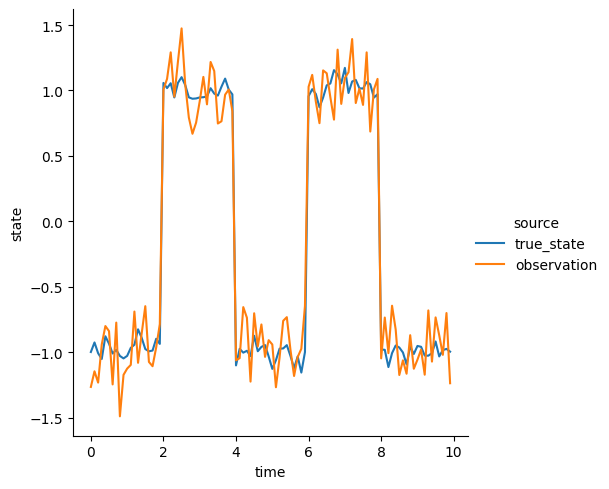

In [105]:
df = (
    pd.DataFrame({k: rearrange(v, 't s -> (t s)').cpu().numpy() for k, v in columns.items()})
    .melt(id_vars='time', var_name='source', value_name='state')
)
sns.relplot(
    data=df,
    kind='line',
    x='time',
    y='state',
    hue='source',
)